# RC Decay Constant Analysis

This notebook estimates the decay time constant $\tau = RC_\mathrm{eff}$ from sensor trajectories.

Workflow:

1. Ingest data of the session. Load the CSV for the desired channel.
2. Convert ADC counts to voltage using a 12-bit, 0–3.3 V conversion.
3. Choose or infer the CH5 column.
4. Apply a 60 Hz notch filter.
5. Detect falling edges corresponding to voltage removal.
6. Fit each decay to a single-exponential model:

$$
V(t) = B + A e^{-t/\tau}
$$

7. Summarize the fitted decay constants.


In [85]:
# ======================================================================
# Imports
# ======================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import iirnotch, filtfilt
from scipy.optimize import curve_fit
from pathlib import Path

from scripts.ingestion import *

In [86]:
# ======================================================================
# From Amir: convert ADC to voltage
# ======================================================================
MIN_VAL = 0
MAX_VAL = 4095   # 12-bit ADC
MIN_VOLT = 0.0
MAX_VOLT = 3.3

def adc_to_voltage(adc_value, adc_min=MIN_VAL, adc_max=MAX_VAL,
                   min_volt=MIN_VOLT, max_volt=MAX_VOLT):
    """
    Convert ADC integer(s) to voltage.
    Accepts scalars or numpy arrays.
    """
    scale = (max_volt - min_volt) / float(adc_max - adc_min)
    return min_volt + (np.array(adc_value) - adc_min) * scale


## Ingest all data of the session

In [49]:
def scan_channel_files(data_dir, channels=range(1, 6)):
    """
    Scan a folder for each channel's data CSV and metadata JSON.

    Expected filenames:
        ch1_20260506_1408.csv
        ch1_20260506_1408_metadata.json

    Parameters
    ----------
    data_dir : str or Path
        Folder containing decay-factor CSV and metadata files.
    channels : iterable[int]
        Channel numbers to scan, e.g. [1, 2, 3, 4, 5].

    Returns
    -------
    summary_df : pd.DataFrame
        One row per channel/session candidate, with paths and existence flags.
    """
    data_dir = Path(data_dir)

    rows = []

    for ch in channels:
        # Data CSVs: include ch{ch}_*.csv, exclude metadata and block timing files
        data_csvs = sorted([
            p for p in data_dir.glob(f"ch{ch}_*.csv")
            if "metadata" not in p.name.lower()
            and "block_timing" not in p.name.lower()
        ])
        print(f"Channel {ch}: Found {len(data_csvs)} data CSV(s).")

        # Metadata files
        metadata_jsons = sorted(data_dir.glob(f"ch{ch}_*_metadata.json"))

        # Make rows based on discovered data CSVs
        for csv_path in data_csvs:
            expected_metadata = csv_path.with_name(csv_path.stem + "_metadata.json")

            rows.append({
                "channel": ch,
                "session": csv_path.stem.replace(f"ch{ch}_", ""),
                "data_csv_exists": True,
                "data_csv": csv_path,
                "metadata_exists": expected_metadata.exists(),
                "metadata_json": expected_metadata if expected_metadata.exists() else None,
            })

        # Also report metadata files that do not have a matching CSV
        matched_metadata = {
            row["metadata_json"]
            for row in rows
            if row["channel"] == ch and row["metadata_json"] is not None
        }

        for metadata_path in metadata_jsons:
            if metadata_path not in matched_metadata:
                session = metadata_path.stem.replace(f"ch{ch}_", "").replace("_metadata", "")

                expected_csv = metadata_path.with_name(
                    metadata_path.stem.replace("_metadata", "") + ".csv"
                )

                rows.append({
                    "channel": ch,
                    "session": session,
                    "data_csv_exists": expected_csv.exists(),
                    "data_csv": expected_csv if expected_csv.exists() else None,
                    "metadata_exists": True,
                    "metadata_json": metadata_path,
                })

    summary_df = pd.DataFrame(rows)

    if len(summary_df) == 0:
        return pd.DataFrame(columns=[
            "channel",
            "session",
            "data_csv_exists",
            "data_csv",
            "metadata_exists",
            "metadata_json",
        ])
    
    return summary_df.sort_values(["channel", "session"]).reset_index(drop=True)

def get_sampling_rate_from_summary_row(row, adc_channel="5"):
    """
    Given one row from file_summary, load its metadata JSON and return
    the per-channel sampling rate.

    Parameters
    ----------
    row : pd.Series
        One row from file_summary.
    adc_channel : str
        ADC channel key in metadata. Since your signal column is always CH5,
        this should usually be "5".

    Returns
    -------
    fs : float
        Sampling rate in Hz.
    """
    metadata_path = row["metadata_json"]

    if metadata_path is None or pd.isna(metadata_path):
        raise FileNotFoundError("This row has no metadata_json path.")

    metadata_path = Path(metadata_path)

    if not metadata_path.exists():
        raise FileNotFoundError(f"Metadata file does not exist: {metadata_path}")

    with open(metadata_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)

    try:
        fs = metadata["filtering"]["per_channel_sample_rates_hz"][str(adc_channel)]
    except KeyError as e:
        raise KeyError(
            f"Could not find sampling rate for ADC channel {adc_channel!r} in metadata."
        ) from e

    return float(fs)

def load_data_from_summary_row(row, adc_channel="5"):
    """
    Given one row from file_summary, load the corresponding CSV data and
    sampling rate from metadata.

    Parameters
    ----------
    row : pd.Series
        One row from file_summary.
    adc_channel : str
        ADC channel key to use for sampling rate in metadata.
        For your files, this is usually "5".

    Returns
    -------
    data : dict
        Contains dataframe, adc counts, voltage, time, sampling rate, and paths.
    """
    csv_path = row["data_csv"]

    if csv_path is None or pd.isna(csv_path):
        raise FileNotFoundError("This row has no data_csv path.")

    csv_path = Path(csv_path)

    if not csv_path.exists():
        raise FileNotFoundError(f"CSV file does not exist: {csv_path}")

    df = pd.read_csv(csv_path)

    signal_col = f"CH{row['channel']}"

    fs = get_sampling_rate_from_summary_row(row, adc_channel=adc_channel)

    adc = df[signal_col].to_numpy()
    voltage = adc_to_voltage(adc)
    t = np.arange(len(voltage)) / fs

    return {
        "channel": row.get("channel", None),
        "session": row.get("session", None),
        "data_csv": csv_path,
        "metadata_json": Path(row["metadata_json"]),
        "df": df,
        "adc": adc,
        "voltage": voltage,
        "t": t,
        "fs": fs,
        "signal_col": signal_col,
        "adc_channel": adc_channel,
    }


In [87]:
# ======================================================================
# Load CSV
# ======================================================================
data_dir = "/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/05_06_decay_factors"

channels = range(1, 6) # CH1 - CH5
session_index = scan_channel_files(data_dir, channels)

Channel 1: Found 1 data CSV(s).
Channel 2: Found 1 data CSV(s).
Channel 3: Found 1 data CSV(s).
Channel 4: Found 1 data CSV(s).
Channel 5: Found 1 data CSV(s).


### Analysis of a single channel

In [88]:
row_id = 0
row = session_index.iloc[row_id]
channel, session = row["channel"], row["session"]
data = load_data_from_summary_row(row)

voltage = data["voltage"]
fs = data["fs"]

print("Channel:", channel)
print("Session:", session)
print("Sampling rate:", fs, "Hz")
print("ADC shape:", data["adc"].shape)
print("Voltage range:", voltage.min(), voltage.max())

Channel: 1
Session: 20260506_1408
Sampling rate: 1490.3129657137288 Hz
ADC shape: (61798,)
Voltage range: 1.6342857142857143 2.6972161172161173


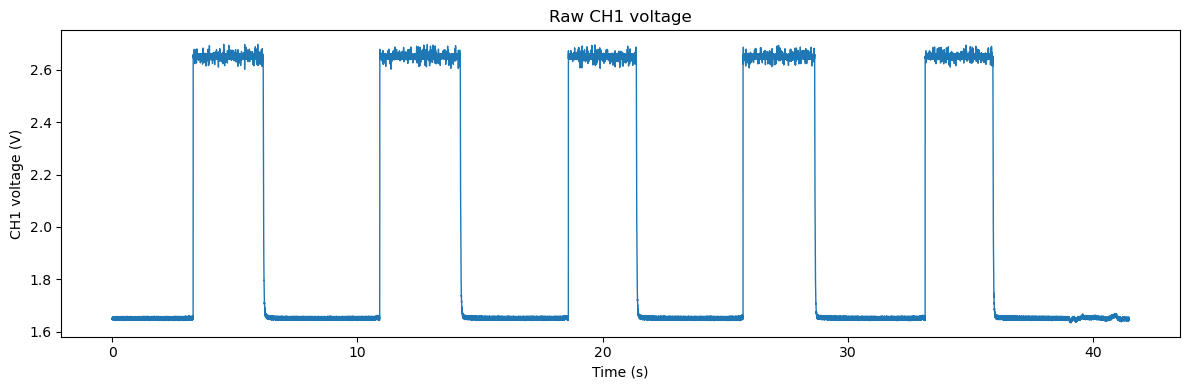

In [89]:
# ======================================================================
# Plot raw CH5 voltage
# ======================================================================
t = np.arange(len(voltage)) / data["fs"]
plt.figure(figsize=(12, 4))
plt.plot(t, voltage, linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel(f"CH{channel} voltage (V)")
plt.title(f"Raw CH{channel} voltage")
plt.tight_layout()
plt.show()


## Apply 60 Hz notch filtering

This removes a narrowband component centered at 60 Hz. You can adjust `quality_factor`:

- Higher `Q`: narrower notch.
- Lower `Q`: wider notch.


In [90]:
# ======================================================================
# 60 Hz notch filter
# ======================================================================
def notch_filter_60hz(x, fs, f0=60.0, quality_factor=30.0):
    """
    Apply a zero-phase IIR notch filter centered at f0.

    Parameters
    ----------
    x : array
        Signal.
    fs : float
        Sampling rate in Hz.
    f0 : float
        Notch frequency, usually 60 Hz in the US.
    quality_factor : float
        Higher values make the notch narrower.
    """
    b, a = iirnotch(w0=f0, Q=quality_factor, fs=fs)
    return filtfilt(b, a, x)

voltage_filt = notch_filter_60hz(voltage, fs=fs, f0=60.0, quality_factor=30.0)


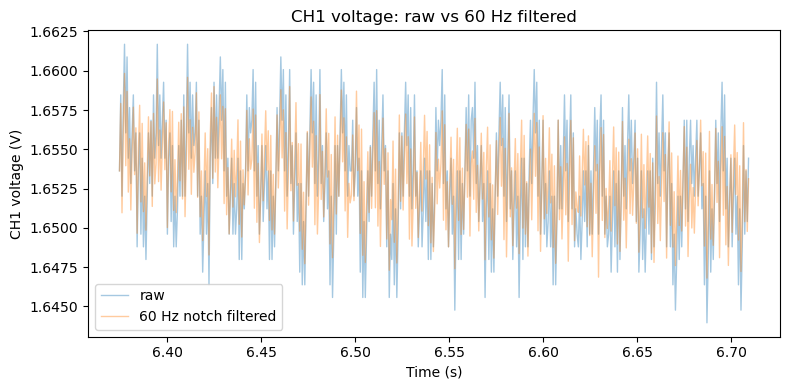

In [91]:
# ======================================================================
# Plot raw vs filtered
# ======================================================================
plt.figure(figsize=(8, 4))

s0, s1 = 9500, 10000
t = np.arange(s0, s1) / data["fs"]

plt.plot(t, voltage[s0:s1], alpha=0.4, label="raw", linewidth=1)
plt.plot(t, voltage_filt[s0:s1], label="60 Hz notch filtered", linewidth=1, alpha=0.4)
plt.xlabel("Time (s)")
plt.ylabel(f"CH{channel} voltage (V)")
plt.title(f"CH{channel} voltage: raw vs 60 Hz filtered")
plt.legend()
plt.tight_layout()
plt.show()


## Detect falling edges

Falling edges are taken as the decay starts, where the signal transitions from the high state back toward baseline.


In [92]:
# ======================================================================
# Detect falling edges
# ======================================================================
x = voltage_filt

# Robust estimates of low/high states.
low_level = np.percentile(x, 10)
high_level = np.percentile(x, 90)

# Midpoint threshold for detecting high -> low transitions.
threshold = 0.5 * (low_level + high_level)

print(f"Low level estimate:  {low_level:.4f} V")
print(f"High level estimate: {high_level:.4f} V")
print(f"Threshold:           {threshold:.4f} V")


Low level estimate:  1.6485 V
High level estimate: 2.6544 V
Threshold:           2.1515 V


In [93]:
# Boolean signal: above threshold or not
above = x > threshold

# Falling edges occur when above goes True -> False
falling_edge_indices = np.where((above[:-1] == True) & (above[1:] == False))[0] + 1

# Enforce minimum spacing between events so we don't count noise fluctuations.
min_spacing_s = 0.2
min_spacing_samples = int(min_spacing_s * fs)

filtered_edges = []
last_edge = -np.inf

for idx in falling_edge_indices:
    if idx - last_edge >= min_spacing_samples:
        filtered_edges.append(idx)
        last_edge = idx

falling_edge_indices = np.array(filtered_edges)

t = np.arange(len(x)) / fs
print("Detected falling edges:")
for i, idx in enumerate(falling_edge_indices, start=1):
    print(f"{i}: sample {idx}, time {t[idx]:.4f} s, voltage {x[idx]:.4f} V")


Detected falling edges:
1: sample 9191, time 6.1672 s, voltage 2.1450 V
2: sample 21167, time 14.2031 s, voltage 2.1463 V
3: sample 31866, time 21.3821 s, voltage 2.1497 V
4: sample 42704, time 28.6544 s, voltage 2.1496 V
5: sample 53534, time 35.9213 s, voltage 2.1493 V


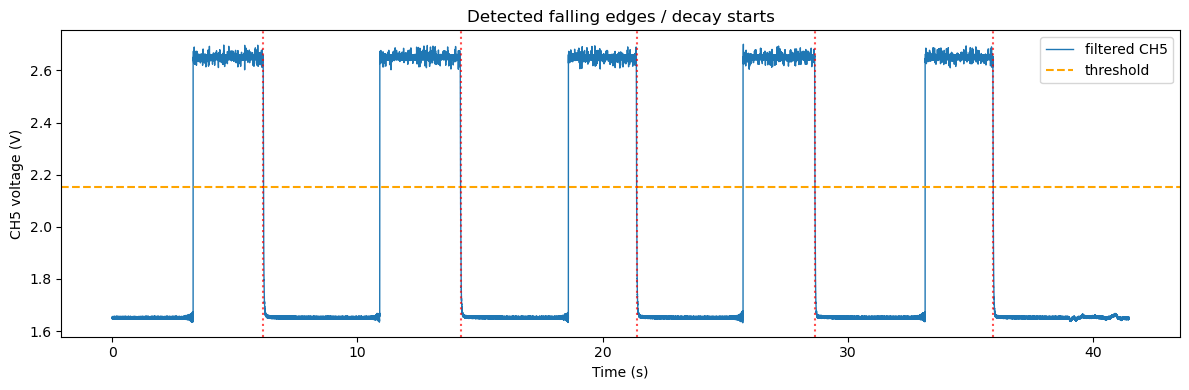

In [98]:
# ======================================================================
# Visual check of detected falling edges
# ======================================================================
plt.figure(figsize=(12, 4))
plt.plot(t, x, label="filtered CH5", linewidth=1)
plt.axhline(threshold, linestyle="--", label="threshold", color="orange")

for idx in falling_edge_indices:
    plt.axvline(t[idx], linestyle=":", alpha=0.7, color="red")

plt.xlabel("Time (s)")
plt.ylabel("CH5 voltage (V)")
plt.title("Detected falling edges / decay starts")
plt.legend()
plt.tight_layout()
plt.show()


## Fit exponential decays

The model is: $V(t) = B + A e^{-t/\tau}$

where $B$ is the baseline, $A$ is the initial amplitude above baseline, $\tau$ is the decay constant.


In [95]:
# ======================================================================
# Exponential model
# ======================================================================
def exp_decay(t_rel, baseline, amplitude, tau):
    """
    Single exponential decay.

    V(t) = baseline + amplitude * exp(-t / tau)
    """
    return baseline + amplitude * np.exp(-t_rel / tau)


In [114]:
# ======================================================================
# Fit each decay
# ======================================================================
fit_window_s = 0.15  # fit first 150 ms after falling edge
fit_window_n = int(fit_window_s * fs)

results = []

for pulse_idx, edge_idx in enumerate(falling_edge_indices, start=1):
    start = edge_idx
    stop = min(edge_idx + fit_window_n, len(x))

    y_fit = x[start:stop]
    t_fit = t[start:stop] - t[start]

    if len(y_fit) < 10:
        continue

    # Estimate baseline from the end of the fitting window.
    baseline_guess = np.median(y_fit[-max(5, len(y_fit)//10):])

    # Initial amplitude estimate.
    amplitude_guess = y_fit[0] - baseline_guess

    # Tau initial guess: around 20 ms.
    tau_guess = 0.020

    p0 = [baseline_guess, amplitude_guess, tau_guess]

    # Bounds:
    # baseline can vary around observed signal;
    # amplitude is positive for high-to-low decay;
    # tau is positive.
    lower_bounds = [np.min(y_fit) - 1.0, 0.0, 1e-4]
    upper_bounds = [np.max(y_fit) + 1.0, 5.0, 1.0]

    try:
        popt, pcov = curve_fit(
            exp_decay,
            t_fit,
            y_fit,
            p0=p0,
            bounds=(lower_bounds, upper_bounds),
            maxfev=10000
        )

        baseline_hat, amplitude_hat, tau_hat = popt

        y_pred = exp_decay(t_fit, *popt)

        # R^2
        ss_res = np.sum((y_fit - y_pred) ** 2)
        ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
        r2 = 1 - ss_res / ss_tot

        results.append({
            "pulse": pulse_idx,
            "edge_sample": edge_idx,
            "edge_time_s": t[edge_idx],
            "baseline_V": baseline_hat,
            "amplitude_V": amplitude_hat,
            "tau_s": tau_hat,
            "tau_ms": tau_hat * 1000,
            "tau_samples": tau_hat * fs,
            "r2": r2
        })

    except RuntimeError as e:
        print(f"Fit failed for pulse {pulse_idx}: {e}")

fit_df = pd.DataFrame(results)
display(fit_df)


,pulse,edge_sample,edge_time_s,baseline_V,amplitude_V,tau_s,tau_ms,tau_samples,r2
0,1,9191,6.167161,1.659233,0.475237,0.017778,17.777540,26.494098,0.998648
1,2,21167,14.203057,1.658278,0.492315,0.018385,18.384688,27.398939,0.998893
2,3,31866,21.382086,1.658344,0.489995,0.017503,17.503069,26.085050,0.998842
3,4,42704,28.654384,1.655424,0.483142,0.017652,17.651991,26.306990,0.998767
4,5,53534,35.921314,1.656458,0.494218,0.017783,17.782696,26.501782,0.998884


In [115]:
# ======================================================================
# Summary statistics
# ======================================================================
mean_tau_ms = fit_df["tau_ms"].mean()
std_tau_ms = fit_df["tau_ms"].std()

mean_tau_samples = fit_df["tau_samples"].mean()
std_tau_samples = fit_df["tau_samples"].std()

print(f"Mean tau: {mean_tau_ms:.3f} ± {std_tau_ms:.3f} ms")
print(f"Mean tau: {mean_tau_samples:.2f} ± {std_tau_samples:.2f} samples")
print()
display(fit_df[["pulse", "tau_ms", "tau_samples", "r2"]])


Mean tau: 17.820 ± 0.336 ms
Mean tau: 26.56 ± 0.50 samples



,pulse,tau_ms,tau_samples,r2
0,1,17.777540,26.494098,0.998648
1,2,18.384688,27.398939,0.998893
2,3,17.503069,26.085050,0.998842
3,4,17.651991,26.306990,0.998767
4,5,17.782696,26.501782,0.998884


## Plot individual fits

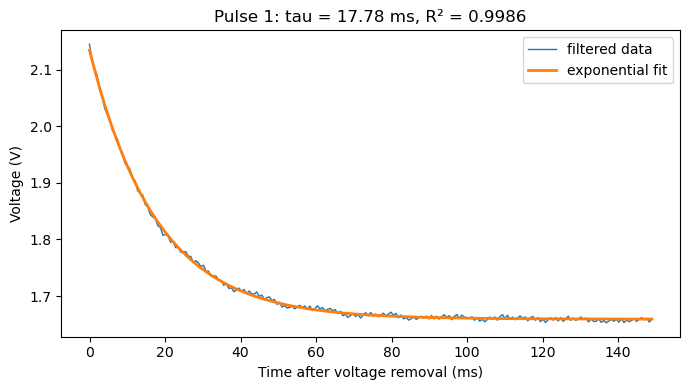

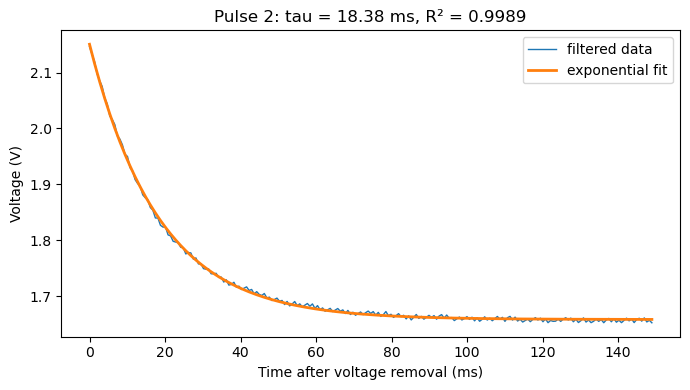

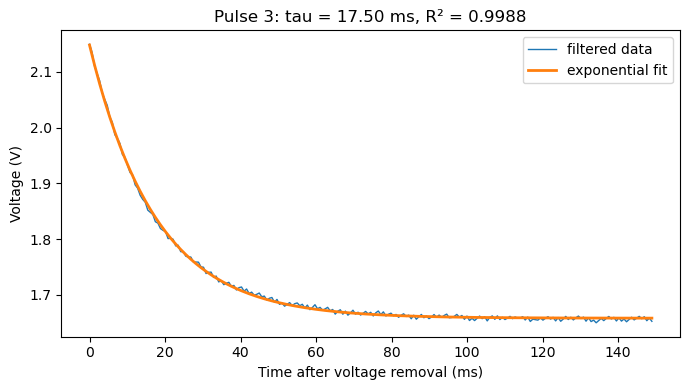

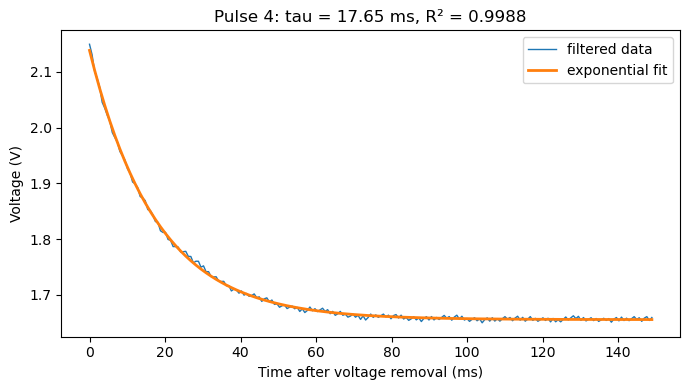

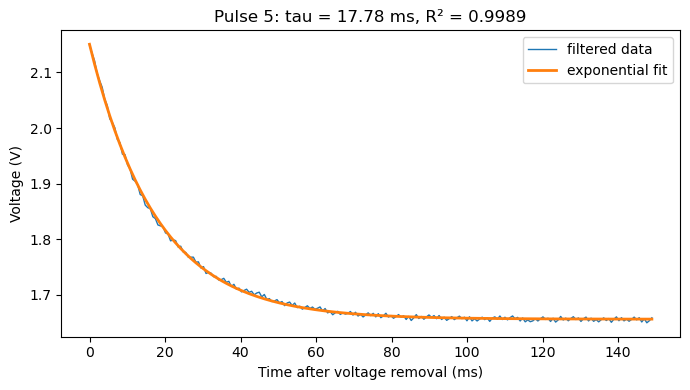

In [116]:
# ======================================================================
# Plot individual fits
# ======================================================================
for _, row in fit_df.iterrows():
    pulse_idx = int(row["pulse"])
    edge_idx = int(row["edge_sample"])

    start = edge_idx
    stop = min(edge_idx + fit_window_n, len(x))

    y_fit = x[start:stop]
    t_fit = t[start:stop] - t[start]

    params = [
        row["baseline_V"],
        row["amplitude_V"],
        row["tau_s"]
    ]

    y_pred = exp_decay(t_fit, *params)

    plt.figure(figsize=(7, 4))
    plt.plot(t_fit * 1000, y_fit, label="filtered data", linewidth=1)
    plt.plot(t_fit * 1000, y_pred, label="exponential fit", linewidth=2)
    plt.xlabel("Time after voltage removal (ms)")
    plt.ylabel("Voltage (V)")
    plt.title(
        f"Pulse {pulse_idx}: tau = {row['tau_ms']:.2f} ms, "
        f"R² = {row['r2']:.4f}"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


## Plot normalized decays overlaid

If all decays share the same time constant, the normalized traces should approximately collapse onto one curve.


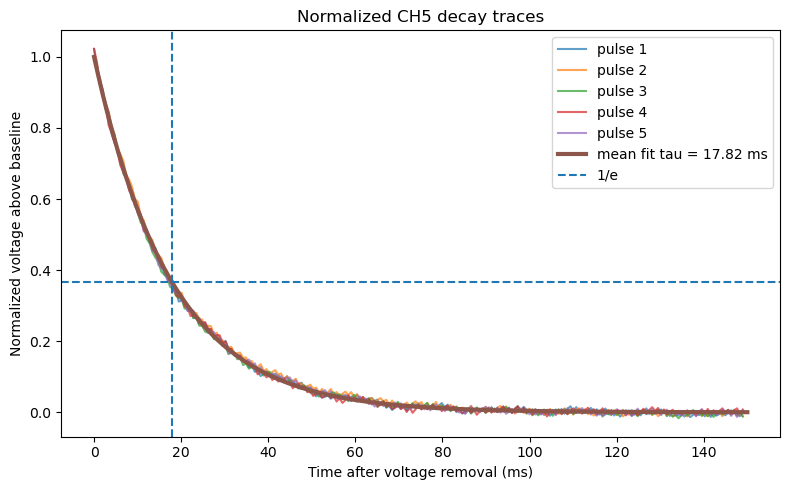

In [117]:
# ======================================================================
# Overlay normalized decays
# ======================================================================
plt.figure(figsize=(8, 5))

for _, row in fit_df.iterrows():
    pulse_idx = int(row["pulse"])
    edge_idx = int(row["edge_sample"])

    start = edge_idx
    stop = min(edge_idx + fit_window_n, len(x))

    y_fit = x[start:stop]
    t_fit = t[start:stop] - t[start]

    baseline = row["baseline_V"]
    amplitude = row["amplitude_V"]

    y_norm = (y_fit - baseline) / amplitude

    plt.plot(t_fit * 1000, y_norm, alpha=0.7, label=f"pulse {pulse_idx}")

# Mean tau curve
tau_mean_s = fit_df["tau_s"].mean()
t_model = np.linspace(0, fit_window_s, 500)
y_model = np.exp(-t_model / tau_mean_s)

plt.plot(t_model * 1000, y_model, linewidth=3, label=f"mean fit tau = {tau_mean_s*1000:.2f} ms")

plt.axhline(np.exp(-1), linestyle="--", label="1/e")
plt.axvline(tau_mean_s * 1000, linestyle="--")

plt.xlabel("Time after voltage removal (ms)")
plt.ylabel("Normalized voltage above baseline")
plt.title("Normalized CH5 decay traces")
plt.legend()
plt.tight_layout()
plt.show()


## Save outputs

In [84]:
# ======================================================================
# Save summary
# ======================================================================
fit_df.to_csv("ch5_decay_fit_summary.csv", index=False)
print("Saved ch5_decay_fit_summary.csv")


Saved ch5_decay_fit_summary.csv


In [ ]:
# ======================================================================
# Save overall filtered trace plot
# ======================================================================
plt.figure(figsize=(12, 4))
plt.plot(t, voltage, alpha=0.35, label="raw", linewidth=1)
plt.plot(t, voltage_filt, label="60 Hz notch filtered", linewidth=1.5)

for idx in falling_edge_indices:
    plt.axvline(t[idx], linestyle=":", alpha=0.6)

plt.xlabel("Time (s)")
plt.ylabel("CH5 voltage (V)")
plt.title("CH5 voltage trace with detected decay starts")
plt.legend()
plt.tight_layout()
plt.savefig("ch5_overall_trace_filtered.png", dpi=200)
plt.show()

print("Saved ch5_overall_trace_filtered.png")


In [ ]:
# ======================================================================
# Save normalized overlay plot
# ======================================================================
plt.figure(figsize=(8, 5))

for _, row in fit_df.iterrows():
    edge_idx = int(row["edge_sample"])

    start = edge_idx
    stop = min(edge_idx + fit_window_n, len(x))

    y_fit = x[start:stop]
    t_fit = t[start:stop] - t[start]

    baseline = row["baseline_V"]
    amplitude = row["amplitude_V"]

    y_norm = (y_fit - baseline) / amplitude
    plt.plot(t_fit * 1000, y_norm, alpha=0.7)

tau_mean_s = fit_df["tau_s"].mean()
t_model = np.linspace(0, fit_window_s, 500)

plt.plot(
    t_model * 1000,
    np.exp(-t_model / tau_mean_s),
    linewidth=3,
    label=f"mean tau = {tau_mean_s*1000:.2f} ms"
)

plt.axhline(np.exp(-1), linestyle="--", label="1/e")
plt.axvline(tau_mean_s * 1000, linestyle="--")

plt.xlabel("Time after voltage removal (ms)")
plt.ylabel("Normalized voltage above baseline")
plt.title("Normalized CH5 decay traces")
plt.legend()
plt.tight_layout()
plt.savefig("ch5_decay_overlay_fit.png", dpi=200)
plt.show()

print("Saved ch5_decay_overlay_fit.png")


## Interpreting the estimate

The most reusable estimate is the decay in **samples**:

$\tau_\text{samples} = \tau_\text{seconds} f_s$

Then convert to seconds using your actual sampling rate:

$\tau_\text{seconds} = \frac{\tau_\text{samples}}{f_s}$

In the prior run, the estimate was approximately:

$\tau \approx 26.85 \text{ samples}$

With $f_s = 1500\,\mathrm{Hz}$:

$\tau \approx 17.9\,\mathrm{ms}$
